In [ ]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATASETS
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE CELL.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote
from urllib.error import HTTPError
from zipfile import ZipFile

CHUNK_SIZE = 40960
DATASET_MAPPING = 'radimagenet-01:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F2940375%2F5064142%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20230425%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20230425T191248Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D01e4f3c23343e968e396673c486a6a03576607dd60f7ed53abca05fc032d17285a6daadfd3b7d6977b73849debed9fd0c9de431f3e8a962e976f350d197ee84a1480def720b124f7a7e4799c5d62405bab14dfa72d353adc782780fb8cd6d517968d4555e4199771db9ecb5e659972164f4c10f3d8ee053eb1ef7800b31f7c1479c2f80d5510e2ae6dc58f1ad42fc369548f0b5add427dfe7fda0325eae0ed37b5aa48c3643c6ca16e8f463c76725c55d3b2a8689f0e60916bc49fa4ae8a1b86404201ad013a133207bef1a6801e6b888069db9bb9d437c54c5cd2f9cc1acda0c5befb01a88cbb137f0d21de502390d0a194f37502dd8f4538528998dec4ed66,meningioma-rgb-generator-4000:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F2995067%2F5154613%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20230425%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20230425T191248Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D70026e3ee2f67a1bc0d4bdf0a5adae40e3d99a47ed7fee821026df08cd1c3e44c9f1bd5477e6b27d0dd5da5d503a66bf654325b4411ce1f47b32c11441650c42dc2ebf91f02bc5923bc8084dee135f80b5d3894d8638311e1b481ba420d3911dad9049411de6d71f8a6b96f0d82b4e484a0e6233c962cac8cbc42c586b94c2069623015336b2525d7cc3c36133f5c0fc4ebc7ff7efc82a36694de5156620f28a001f80f01eba8bb519aa6849f14d42b28e3308230a7be6cca61a5d9db1ae51c1cc0f151835c1684ffb4d12a66443bc4e80f7a22aea3ea93d000242ed357379deca4aa876320fec419096d39475c732178762f46be9a5a651f7ff4ab53e415335,pituitary-rgb-gen-3000:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F3049655%2F5241427%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20230425%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20230425T191248Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D4ee6020a852580c70af58fbfee3fcd37b1e377761977f7211a4a25dfd181436601de792dc439a7b44f1a1230bbcb4660d2383b1adcd0ec836f6ebc9769d24127f2fb9e90773087d5b2c9dbcfac3bf410d02076220f57264130f76c10906104b08a13b758a6c591af9451360e5d78b03133a75fdd4de4ae1d187f63994a57a7e432698731ec60463caaa8adebbe9583879f75d1e71ce59418f5a5add68a4d8e782871105747bc888b648bfffc9aa7a32064d3004858407394e29deccc0671db522f006b2a4223f932b1565d6cd9160a759282e368e24bd0ad40f25fc115d859f084bce79d48ad392c2c24b0f0e6818c7b10c0b6cc7f782b517706a443f1e5436a,dataset03-raw-notcropped:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F3079480%2F5296155%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20230425%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20230425T191248Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D317c481f5fcc255bb2f6eee592110544276c151d386557fa1b60849703997c2536c26da91473ad7e5b136f0f41f394c196bab5cb24267fb198f8b7c1ed986f98d80c8896b9433ec80c221655418862d4b30c9a69ea173f1550a0a267e9d036501e4f5dc967310bad8d25aa9e28abb38b6b7e1dfdcdc0e85d95e8261915aef250d3cb58666f8e2e761816a56a018d7cc9e44c7f1082129ef374d68a22fbab25a1a0118cef526de009e540738742d01b2906713fc1d88e4d37718816175fab76a6b4b5f8281946da2cfff61585c52ad0cbd2a0fe129f28b1eeab25b9d57f3607aa6709bdd0642ae4e6668d48e3bd407111bf1800462c4c7bd0b9fd924e9345eef0'
KAGGLE_INPUT_PATH='/home/kaggle/input'
KAGGLE_INPUT_SYMLINK='/kaggle'

os.makedirs(KAGGLE_INPUT_PATH, 777)
os.symlink(KAGGLE_INPUT_PATH, os.path.join('..', 'input'), target_is_directory=True)
os.makedirs(KAGGLE_INPUT_SYMLINK)
os.symlink(KAGGLE_INPUT_PATH, os.path.join(KAGGLE_INPUT_SYMLINK, 'input'), target_is_directory=True)

for dataset_mapping in DATASET_MAPPING.split(','):
    directory, download_url_encoded = dataset_mapping.split(':')
    download_url = unquote(download_url_encoded)
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as zipfileres, NamedTemporaryFile() as tfile:
            total_length = zipfileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes zipped')
            dl = 0
            data = zipfileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = zipfileres.read(CHUNK_SIZE)
            print(f'\nUnzipping {directory}')
            with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue
print('Dataset import complete.')


In [1]:
!pip install tf-models-official==2.11.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 39.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 28.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.6/636.6 kB 45.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.9/238.9 kB 21.9 MB/s eta 0:00:00
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp37-cp37m-linux_x86_64.whl size

In [2]:
pip install imutils

  Preparing metadata (setup.py) ... done
  Created wheel for imutils: filename=imutils-0.5.4-py3-none-any.whl size=25861 sha256=38bde69087774a0f8a937466844bc6e29284ec3590fbe90d57ef78b06370bdce
  Stored in directory: /root/.cache/pip/wheels/35/e4/69/cb99d996d14a2971b79b990d68b05a17d58ce530ff96090dfc
Successfully built imutils
Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install pipreqs

In [4]:
!pip install wandb --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.14.0
    Uninstalling wandb-0.14.0:
      Successfully uninstalled wandb-0.14.0


In [5]:
import wandb
# wandb.login()
# !wandb login --relogin
wandb.login()
# ba7763a708af8049d06899afff93c2a856fa2373

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

# Import Packages

In [6]:
import os
import random
import gc
import numpy as np
import pandas as pd
import cv2
import imutils

from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rcParams
import seaborn as sns
from PIL import Image
# from imageio import imwrite

import seaborn as sns


import tensorflow as tf
import tensorflow_models as tfm
import tensorflow_probability as tfp

from tensorflow import keras
# from tensorflow.keras import backend
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import (
    InceptionResNetV2,
    ResNet50,
)
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, GlobalAveragePooling2D, LeakyReLU, BatchNormalization
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, CSVLogger, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adamax
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.metrics import Accuracy, Precision, Recall, AUC, TopKCategoricalAccuracy, TruePositives, FalsePositives, TrueNegatives, FalseNegatives
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


Imported


# File Links

In [8]:
path = '/kaggle/input/dataset03-raw-notcropped/Resized'

model_dir = '/kaggle/input/radimagenet-01/RadImageNet-IRV2_notop.h5'

Meningioma_generator_dir = '/kaggle/input/meningioma-rgb-generator-4000/Menin_RGB_generator_model_4000.h5' 
Pituitary_generator_dir = '/kaggle/input/pituitary-rgb-gen-3000/Pituitary_RGB_generator_3000_0.5_drop.h5'

CODE_OUTPUTS = '/kaggle/working/'
csv_logger = CSVLogger(f'{CODE_OUTPUTS}training.log')

# Helper Functions

In [10]:
def display_images(images, name):
    # Display 9 Images
    images = np.reshape(images, (-1, images.shape[1], images.shape[2], images.shape[3]))
    fig, axes = plt.subplots(3, 3, figsize=(6, 6), facecolor='none', linewidth=0.05)
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
    for i, ax in enumerate(axes.flat):
        ax.axis("off")
        image = images[i, :, :, 0]
        ax.imshow(image, cmap="gray")
    plt.savefig(
        f'{CODE_OUTPUTS}{name}image.jpg',
        dpi=300,
        transparent=True,
    )
    plt.show()
    plt.close()
    
def visualize_distribution(images1, images2, count):
    fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18, 10))

    images1 = images1[:count]
    sns.distplot(images1, label="Real Images", hist=True, color="#fc0328", ax=axs)
    if images2 != None:
        images2 = images2[:count]
        sns.distplot(images2, label="Generated Images", hist=True, color="#0c06c7", ax=axs)
    axs.legend(loc="upper right", prop={"size": 12})
    pyplot.savefig(
        distribution,
        bbox_inches="tight",
        transparent=True,
    )
    plt.show()
    plt.close()

def visualize_class_distribution(classes, name):
    fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(18, 10))
    sns.distplot(classes, label= name, hist=True, color="#fc0328", ax=axs)
    plt.savefig(
        f"class_distribution_{name}.jpg",
        bbox_inches="tight",
        transparent=True,
        dpi= 300,
    )
    plt.show()
    plt.close()
    

# Variables Setup

In [11]:

LATENT_DIM = 100
DISPLAY_GENRATED_SAMPLES = 10
BATCH_SIZE = 32
IMAGE_SIZE = 128

TRAIN_RATIO = 0.80
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.10

CROPPED = False
ENHANCED = True

CLASSIC_AUG = True
GAN_AUG = True
MIXUP_AUG = True

AUGMENT_GLIOMA = False
AUGMENT_MENINGIOMA = True
AUGMENT_PITUITARY = True

AUGMENTATION_RATE = 50
GLIOMA_AUGMENTATION_NUM= 0
MENINGIOMA_AUGMENTATION_NUM = 10 
PITUITARY_AUGMENTATION_NUM = 7 


# Preprocessing & Enhancement

In [12]:
def crop_image(image_to_crop):
    img_size = image_to_crop.shape
   
    gray = cv2.cvtColor(image_to_crop, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # threshold the image, then perform a series of erosions +
    # dilations to remove any small regions of noise
    thresh = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # find contours in thresholded image, then grab the largest one
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)

    # find the extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])

    # add contour on the image
    img_cnt = cv2.drawContours(image_to_crop.copy(), [c], -1, (0, 255, 255), 4)
    
    # add extreme points
    img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0, 0, 255), -1)
    img_pnt = cv2.circle(img_pnt, extRight, 8, (0, 255, 0), -1)
    img_pnt = cv2.circle(img_pnt, extTop, 8, (255, 0, 0), -1)
    img_pnt = cv2.circle(img_pnt, extBot, 8, (255, 255, 0), -1)

    # crop
    ADD_PIXELS = 0
    Cropped_image = image_to_crop[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
    return Cropped_image
def Enhancement(image):
    
    NOISE_FLOOR = 15

    def reduce_noise(noisy_img, noise_floor=NOISE_FLOOR):

        clean_img = noisy_img
        clean_img[noisy_img < NOISE_FLOOR] = 0
        return clean_img

    def eualize_darken(image):        

        new_img = cv2.bilateralFilter(image,1,10,10)
        img_hsv = cv2.cvtColor(new_img, cv2.COLOR_RGB2YCrCb)
        img_hsv[:, :, 0] = cv2.equalizeHist(img_hsv[:, :, 0])
        image = cv2.cvtColor(img_hsv, cv2.COLOR_YCrCb2RGB)  
        return image

    def gammaCorrection(src, gamma):

        image = src.astype(np.float32) / 255.0

        gamma_corrected = np.power(image, gamma)

        # Convert the gamma-corrected image back to uint8
        image = (gamma_corrected * 255).clip(0, 255).astype(np.uint8)
        return image
    image = reduce_noise(image)
    image = eualize_darken(image)
    image = gammaCorrection(image, 1.6)

    return image

# Import Data

There are 1426 samples in the class glioma_cropped
There are 708 samples in the class meningioma_cropped
There are 930 samples in the class pituitary_cropped
Images:  (3064, 128, 128, 3)
Labels:  (3064,)


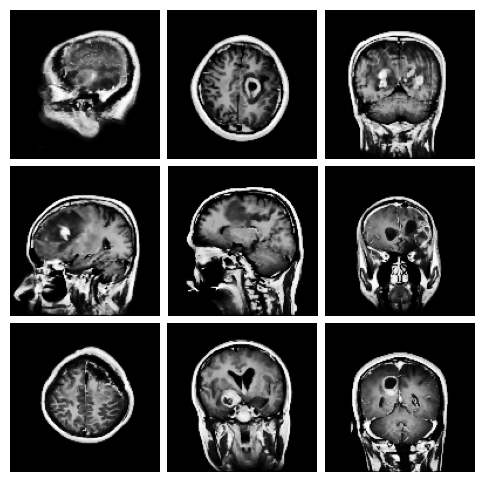

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



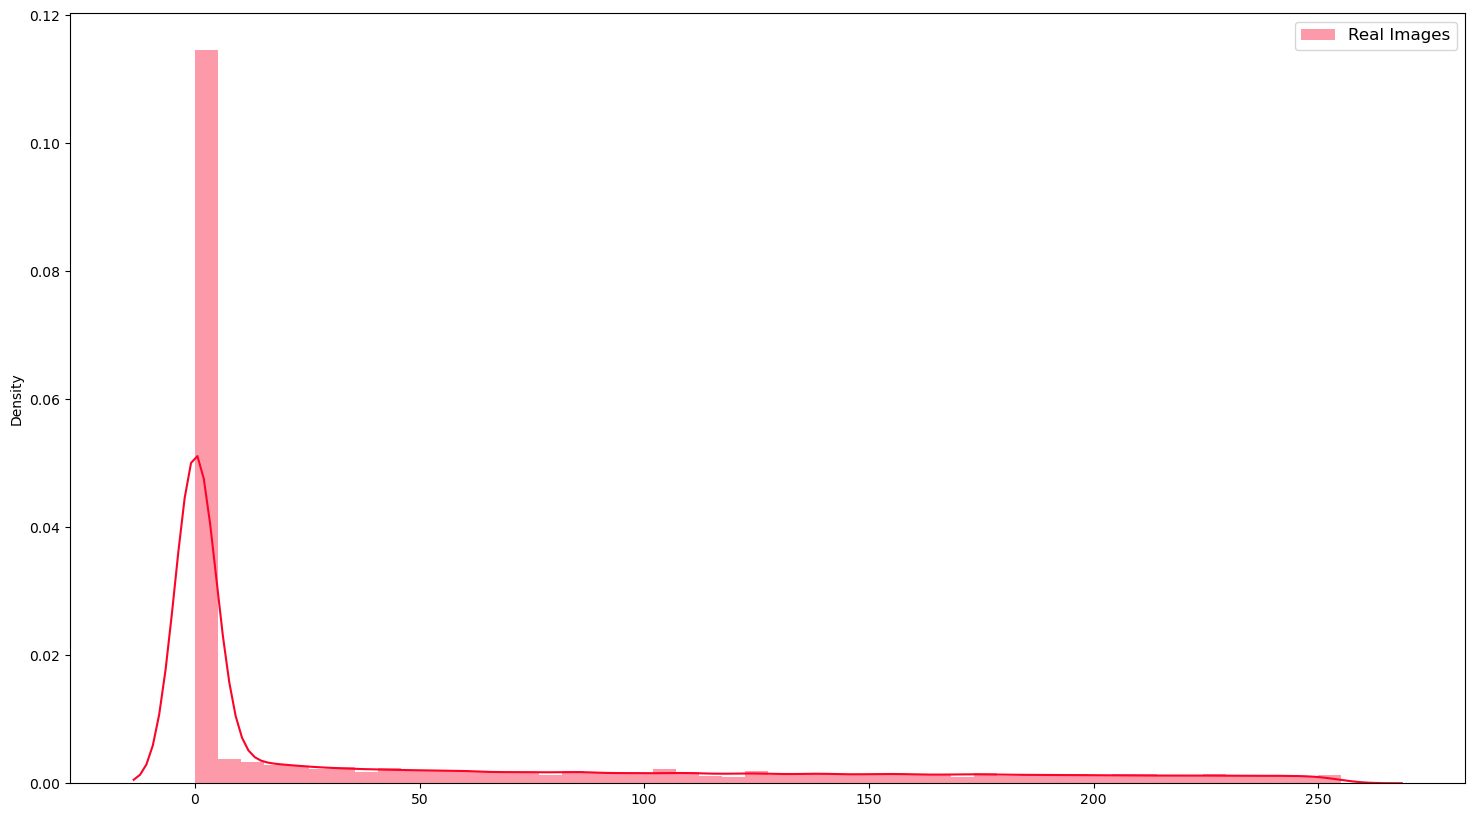

In [13]:
Images = []
Labels = []
Classes = ['glioma_cropped', 'meningioma_cropped', 'pituitary_cropped']
classes_dict = {'glioma_cropped': 0, 'meningioma_cropped':1, 'pituitary_cropped':2}

for Class in classes_dict.keys():
    class_samples = 0
    cpath = os.path.join(path, Class)
    cpath += '/'
    for img in os.listdir(cpath):
        class_samples += 1

        image = cv2.imread(os.path.join(cpath, img), cv2.IMREAD_COLOR)   
        if CROPPED == True:
            image = crop_image(image)
        image = cv2.resize(image, (128, 128))
        image = Enhancement(image)
        
        Images.append(image)
        Labels.append(classes_dict[Class])
    print(f"There are {class_samples} samples in the class {Class}")


Images = np.array(Images)
Labels = np.array(Labels)

print("Images: ", Images.shape)
print("Labels: ", Labels.shape)


display_images(Images, 'data_import')
visualize_distribution(Images, None, 20)

# Split data 80:10:10

x_train:  (2451, 128, 128, 3)
x_val:  (306, 128, 128, 3)
x_test:  (307, 128, 128, 3)
Images:  (2451, 128, 128, 3)
Labels:  (2451,)


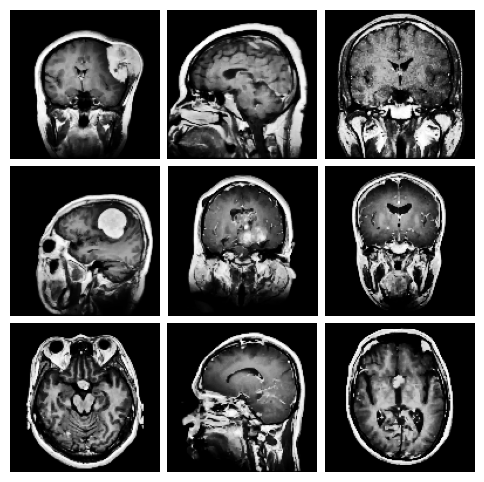

Images:  (306, 128, 128, 3)
Labels:  (306,)
Images:  (307, 128, 128, 3)
Labels:  (307,)


48148

In [15]:
x_train, x_val_tmp, y_train, y_val_tmp = train_test_split(Images, Labels, test_size= 1 - TRAIN_RATIO, random_state= 16, shuffle= True, stratify= Labels)

x_val, x_test, y_val, y_test = train_test_split(x_val_tmp, y_val_tmp, test_size=TEST_RATIO/(TEST_RATIO + VALIDATION_RATIO), random_state= 16, shuffle= True, stratify= y_val_tmp) 

print("x_train: ", x_train.shape)
print("x_val: ", x_val.shape)
print("x_test: ", x_test.shape)


# Calculate the mean and standard deviation of the training set only
train_means = np.mean(x_train, axis=(0, 1, 2))
train_stdevs = np.std(x_train, axis=(0, 1, 2))

# Normalize all sets using the training set statistics
x_train = (x_train - train_means) / train_stdevs
x_val = (x_val - train_means) / train_stdevs


# Check the mean and standard deviation of each channel in the normalized data
channel_means = np.mean(x_train, axis=(0, 1, 2))
channel_stdevs = np.std(x_train, axis=(0, 1, 2))

Images_list = []
for image in x_train:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

    image = (image * 2) - 1
    Images_list.append(image)
x_train = np.array(Images_list)
print("Images: ", x_train.shape)
print("Labels: ", y_train.shape)
display_images(x_train, 'x_train')
visualize_distribution(x_train, None, 20)

del Images_list

Images_list = []
for image in x_val:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

# #     Rescale the pixel values to be between -1 and 1
    image = (image * 2) - 1
    Images_list.append(image)
x_val = np.array(Images_list)
print("Images: ", x_val.shape)
print("Labels: ", y_val.shape)

Images_list = []
for image in x_test:
    image = (image - np.min(image)) / (np.max(image) - np.min(image))

# #     Rescale the pixel values to be between -1 and 1
    image = (image * 2) - 1
    Images_list.append(image)
x_test = np.array(Images_list)
print("Images: ", x_test.shape)
print("Labels: ", y_test.shape)
display_images(x_val, 'x_val')


# Cleaning Memoiry
del Images
del Labels
del Images_list

gc.collect()


# Get the number samples for each class and how much oversampling is necessary

In [16]:
n= len(x_train) # 2305
print(f"There are {n} samples.")

# Split the data and labels by label type
data_by_label = [[] for _ in range(3)]
labels_by_label = [[] for _ in range(3)]
for i in range(n):
    label = y_train[i]
    data_by_label[label].append(x_train[i])
    labels_by_label[label].append(y_train[i])

# Convert the lists to arrays
for i in range(3):
    data_by_label[i] = np.array(data_by_label[i])
    labels_by_label[i] = np.array(labels_by_label[i])


classes = {"0":'glioma_tumor', "1":'meningioma_tumor', "2": 'pituitary_tumor'}
class_distribution = {}

for label in range(3):
  class_name = classes[str(label)]
  class_samples = len(labels_by_label[label])
  
  class_distribution[class_name] = class_samples
  print(f"There are {class_samples} samples in the {class_name} class.")

print("class_distribution: ", class_distribution)
class_imbalance = {}
majority_class = max(class_distribution.values())
for k, v in class_distribution.items():
  if v != majority_class:
    class_imbalance[k]= majority_class - v

print("class_imbalance: ", class_imbalance) 


There are 2451 samples.
There are 1141 samples in the glioma_tumor class.
There are 566 samples in the meningioma_tumor class.
There are 744 samples in the pituitary_tumor class.
class_distribution:  {'glioma_tumor': 1141, 'meningioma_tumor': 566, 'pituitary_tumor': 744}
class_imbalance:  {'meningioma_tumor': 575, 'pituitary_tumor': 397}


# Classic Augmentation

In [17]:
classic_agmentation = tf.keras.preprocessing.image.ImageDataGenerator(
  horizontal_flip = True,
#   vertical_flip = True,
  width_shift_range = 0.2,
  height_shift_range = 0.2,
  shear_range = 0.1,
  rotation_range = 90,
  fill_mode= 'constant',
  cval= 0,
  zoom_range = [0.5, 0.8]
  )

reverse_class_label = {'glioma_tumor':0, 'meningioma_tumor': 1, 'pituitary_tumor': 2}
class_imbalance = {'glioma_tumor':550, 'meningioma_tumor': 550, 'pituitary_tumor': 550}

print("class_imbalance: ", class_imbalance)

data_to_augment = data_by_label
label_to_augment = labels_by_label


def classic_augmentation(Images, Labels, class_to_augment):
  print("---------------- Augmenting ----------------")
  generated_images = 0
  target_size = class_imbalance[class_to_augment]

  augmmentation_rate = random.randint(1, 2)

  print("Generating Images...")
  augmented_labels= []

  print(f"the Input data: {Images.shape}")
  
  augmented_images_list = []
  for i in range(target_size):
    selector = random.randint(0, target_size-40)
    images_to_augment = Images[selector]
    images_to_augment = images_to_augment.reshape((1, IMAGE_SIZE, IMAGE_SIZE, 3))
    augmented_data = classic_agmentation.flow(
      images_to_augment, 
      shuffle= True,
      seed= 22, 
      batch_size= BATCH_SIZE
    )
    augmented_images_list.append(augmented_data.x)

  augmented_images_list = np.array(augmented_images_list)
  augmented_images_list = np.squeeze(augmented_images_list, axis=1)
  print("Done")
  print(len(augmented_images_list))
 
  display_images(augmented_images_list, 'classic_aug')
 
  for i in range(len(augmented_images_list)):
        augmented_labels.append(reverse_class_label[class_to_augment])
  print('augmented_labels: ', len(augmented_labels))

  return np.array(augmented_images_list), np.array(augmented_labels)

class_imbalance:  {'glioma_tumor': 550, 'meningioma_tumor': 550, 'pituitary_tumor': 550}


# DCGAN Augmentation

In [18]:
def GAN_Augmentation(model_dir, label, augmentation_number, augmentation_rate):
    
    generator = load_model(model_dir)
    
    gen_imgs= []
    gen_lbls= []
    generated_labels = []
    interation = 1

    for i in range(augmentation_number): 
        noise = tf.random.normal([augmentation_rate, LATENT_DIM])
        GENERATED_IMAGE = generator(noise, training=False)
        generated_images = []
        for i in range(augmentation_rate):
            generated = GENERATED_IMAGE[i]
            generated = np.array(generated)
            generated = ((generated + 1) / 2) * 255.0
            generated = np.uint8(generated)

            generated = Enhancement(generated.astype(np.uint8))
            generated = (generated - np.min(generated)) / (np.max(generated) - np.min(generated))
          # Rescale the pixel values to be between -1 and 1
            generated = (generated * 2) - 1
        
            generated_images.append(generated)  
        
        gen_imgs.extend(generated_images)
        interation += 1
    print(f'Generated {len(gen_imgs)} images')
    print("---------------- Process Finished ----------------")
    for i in range(augmentation_number):
        for i in range(augmentation_rate):
            generated_labels.append(label)
    gen_lbls.extend(generated_labels)
    print(f'Generated {len(gen_lbls)} labels')
 
    
    return gen_imgs, gen_lbls

# Mixup Augmentation

In [19]:
def MixUp(images, labels):
    
    images = tf.convert_to_tensor(images)
    labels = tf.convert_to_tensor(labels)
    print(images.shape)
    mx = tfm.vision.augment.MixupAndCutmix
    new_img, new_lbl = mx(mixup_alpha= 0.1, num_classes= 3, cutmix_alpha= 0).distort(images, labels)
    mixed_up_images = np.array(new_img)
    mixed_up_labels = np.array(new_lbl)

    display_images(np.array(mixed_up_images), "MixUP")
#     visualize_distribution(mixed_up_images, None, 20) 
    return mixed_up_images, mixed_up_labels

def gammaCorrection(src, gamma):
    image = src.astype(np.float32) / 255.0
    gamma_corrected = np.power(image, gamma)

    image = (gamma_corrected * 255).clip(0, 255).astype(np.uint8)
    return image

def zscore_normalize(Images):
    Images_list = []
    Images = (Images - train_means) / train_stdevs

    Images_list = []
    for image in Images:
        
        image = (image - np.min(image)) / (np.max(image) - np.min(image))
        image = (image * 2) - 1

        Images_list.append(image)
    Images = np.array(Images_list)
    print("Images: ", Images.shape)
    display_images(Images, 'Images')
    visualize_distribution(Images, None, 20)
    return Images

# Augmentation Framework

Class Distribution before augmentation: 
---------------- Classic Augmentation ----------------
---------------- Augmenting ----------------
Generating Images...
the Input data: (1141, 128, 128, 3)
Done
550


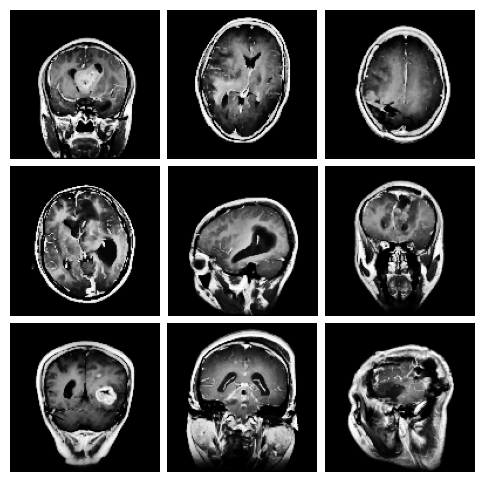

augmented_labels:  550
Glioma_Images:  (550, 128, 128, 3)
Glioma_Labels:  (550,)
---------------- Augmenting ----------------
Generating Images...
the Input data: (566, 128, 128, 3)
Done
550


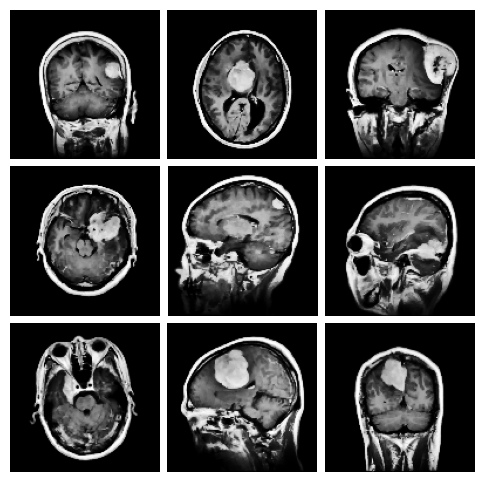

augmented_labels:  550
Menin_Images:  (550, 128, 128, 3)
Menin_Labels:  (550,)
---------------- Augmenting ----------------
Generating Images...
the Input data: (744, 128, 128, 3)
Done
550


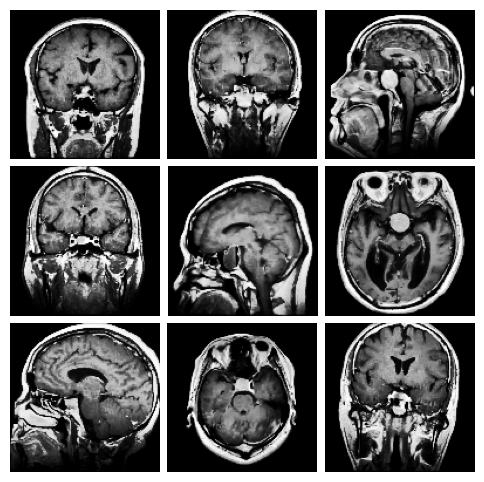

augmented_labels:  550
Pit_Images:  (550, 128, 128, 3)
Pit_Labels:  (550,)
---------------- GAN Augmentation ----------------
--------------- Meningioma Augmentation ---------------
Generated 500 images
---------------- Process Finished ----------------
Generated 500 labels
Images:  (500, 128, 128, 3)


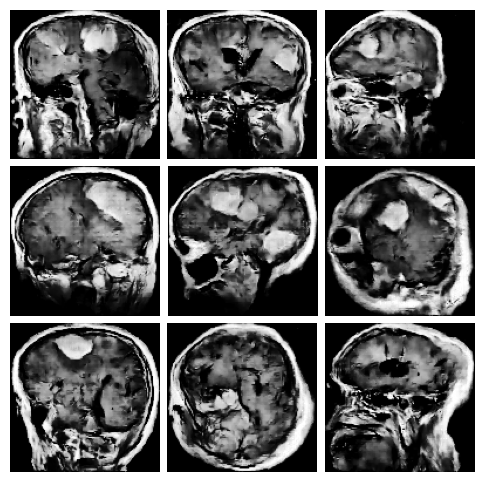

Train shape: (4101, 128, 128, 3), generated_images shape: (500, 128, 128, 3)
Post_GAN_augmented_train_images shape:  (4601, 128, 128, 3)
---------------------------

y_train shape: (4101,), generated_labels shape: (500,)
augmented_train_labels shape:  (4601,)
--------------- Pituitary Augmentation ---------------
Generated 350 images
---------------- Process Finished ----------------
Generated 350 labels
Images:  (350, 128, 128, 3)


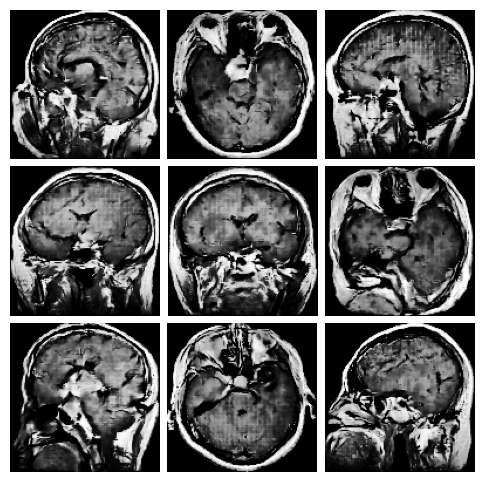

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



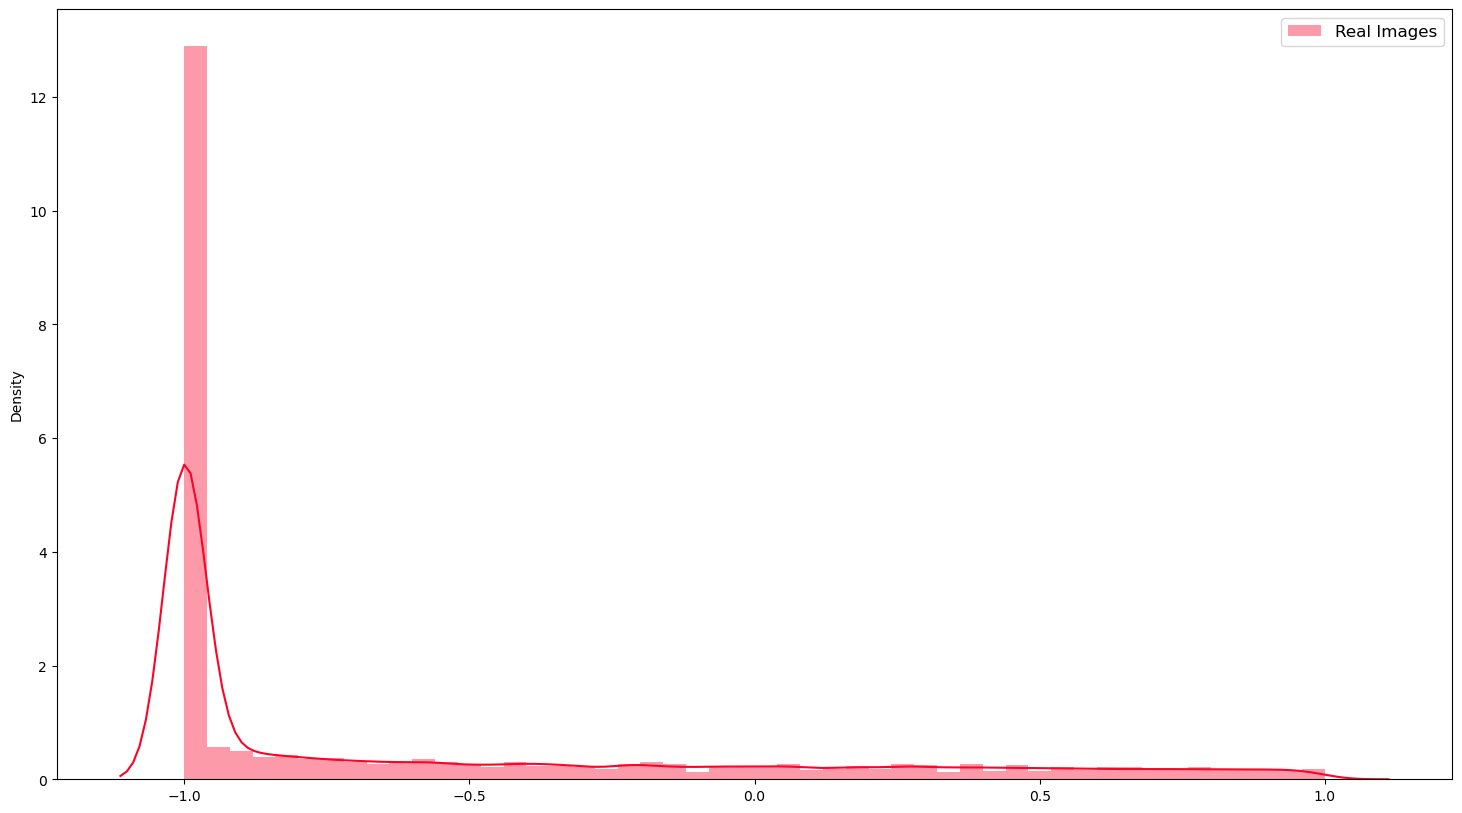

augmented_train_images shape: (4601, 128, 128, 3), generated_images shape: (350, 128, 128, 3)
Post_GAN_augmented_train_images shape:  (4951, 128, 128, 3)
---------------------------

augmented_train_labels shape: (4601,), generated_labels shape: (350,)
augmented_train_labels shape:  (4951,)
Images type:  float32
---------------- Mix Up Augmentation ----------------
Images:  (4951, 128, 128, 3)
(4951, 128, 128, 3)


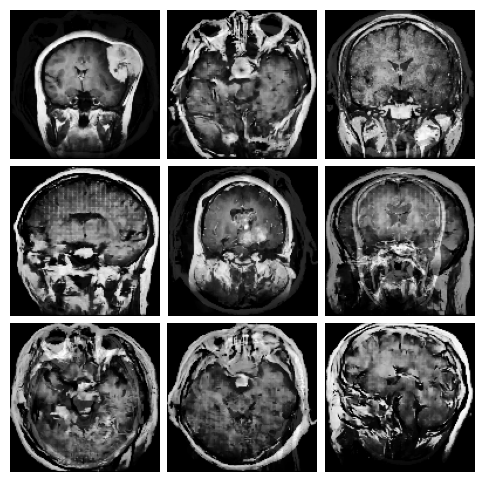

augmented_train_images: (4951, 128, 128, 3), augmented_train_labels: (4951,)
Train Images Set After Mixup Augmentation:  (9902, 128, 128, 3)
Train Labels Set After Mixup Augmentation:  (9902, 3)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:41: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



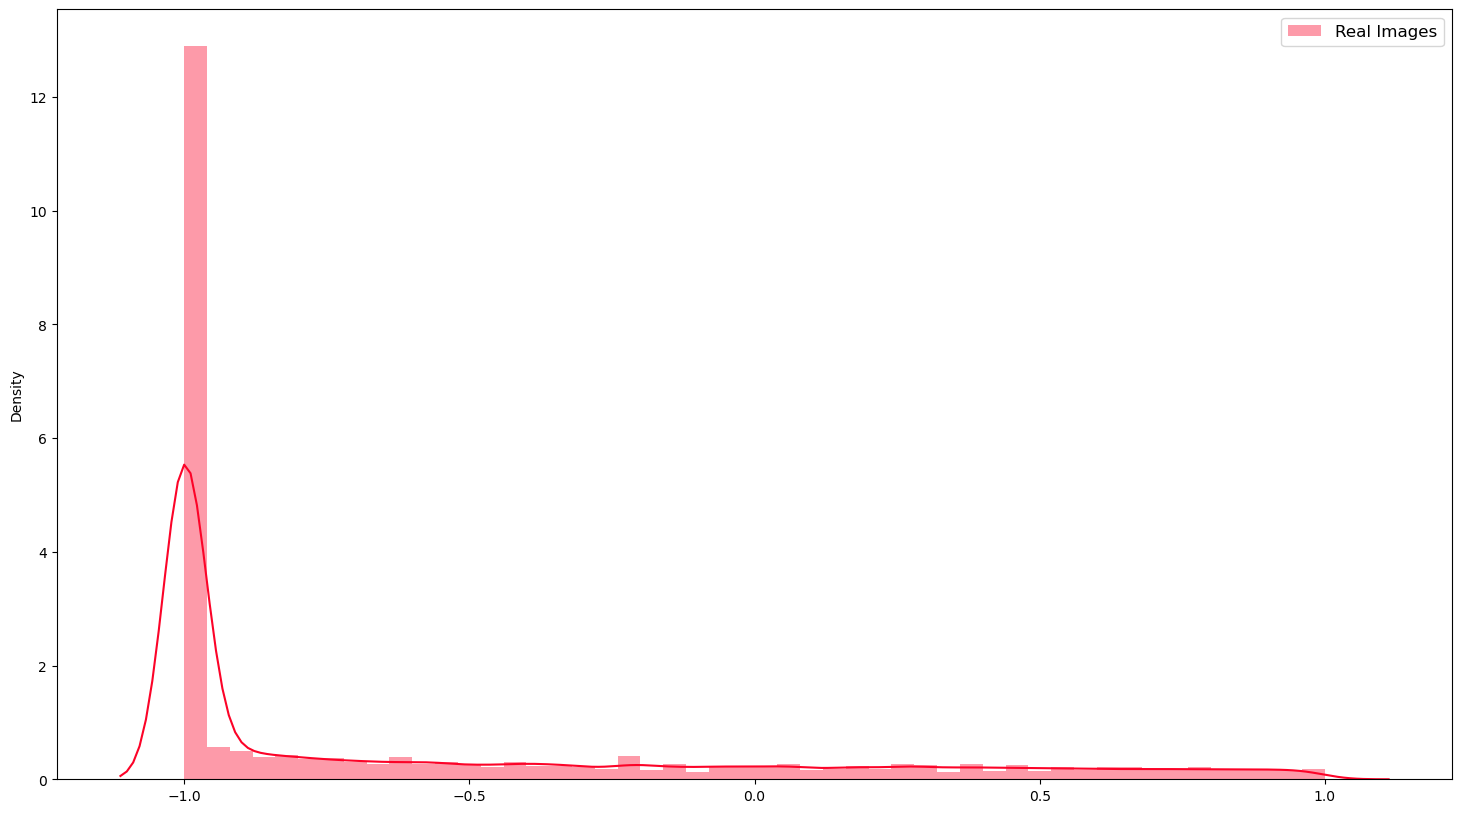

In [20]:
print("Class Distribution before augmentation: ")
# visualize_class_distribution(y_train, "Pre_Aug")
np.savetxt(f"{CODE_OUTPUTS}Pre_Aug.csv", y_train, delimiter =", ", fmt ='% s')

def Augmentation_framework(CLASSIC_AUG, GAN_AUG, MIXUP_AUG, Images, Labels, y_val):
    if CLASSIC_AUG == True:
        print("---------------- Classic Augmentation ----------------")
        Glioma_Images, Glioma_Labels= classic_augmentation(data_to_augment[0], label_to_augment[0], 'glioma_tumor')
        print("Glioma_Images: ", Glioma_Images.shape)
        print("Glioma_Labels: ", Glioma_Labels.shape)

        Menin_Images, Menin_Labels= classic_augmentation(data_to_augment[1], label_to_augment[1], 'meningioma_tumor')
        print("Menin_Images: ", Menin_Images.shape)
        print("Menin_Labels: ", Menin_Labels.shape)
        
        Pit_Images, Pit_Labels= classic_augmentation(data_to_augment[2], label_to_augment[2], 'pituitary_tumor')
        print("Pit_Images: ", Pit_Images.shape)
        print("Pit_Labels: ", Pit_Labels.shape)

        # Combine the classically augmented classes to the rest of the x_train
        Images = np.concatenate((Images, Glioma_Images, Menin_Images, Pit_Images ), axis=0)
        Labels = np.concatenate((Labels, Glioma_Labels, Menin_Labels, Pit_Labels), axis=0)

        del Menin_Images
        del Menin_Labels
        del Pit_Images
        del Pit_Labels
        gc.collect()


    if GAN_AUG == True:
        print("---------------- GAN Augmentation ----------------")
        if AUGMENT_MENINGIOMA == True:
            print("--------------- Meningioma Augmentation ---------------")
            generated_images, generated_labels = GAN_Augmentation(Meningioma_generator_dir, 1, AUGMENTATION_RATE, MENINGIOMA_AUGMENTATION_NUM)
            generated_images = np.array(generated_images)
            generated_labels = np.array(generated_labels)
            generated_images = zscore_normalize(generated_images)
            display_images(np.array(generated_images), 'GAN_images')
            visualize_distribution(Images, None, 20)


            print(f"Train shape: {Images.shape}, generated_images shape: {generated_images.shape}")
            Images = np.concatenate((Images, generated_images), axis=0)
            print("Post_GAN_augmented_train_images shape: ", Images.shape)
            print("---------------------------\n")

            print(f"y_train shape: {Labels.shape}, generated_labels shape: {generated_labels.shape}")
            Labels = np.concatenate((Labels, generated_labels), axis=0)
            print("augmented_train_labels shape: ", Labels.shape)


        if AUGMENT_PITUITARY == True:
            print("--------------- Pituitary Augmentation ---------------")
            generated_images, generated_labels = GAN_Augmentation(Pituitary_generator_dir, 2, AUGMENTATION_RATE, PITUITARY_AUGMENTATION_NUM)
            generated_images = np.array(generated_images)
            generated_labels = np.array(generated_labels)
            generated_images = zscore_normalize(generated_images)
            display_images(np.array(generated_images), 'GAN_images')
            visualize_distribution(Images, None, 20)

            print(f"augmented_train_images shape: { Images.shape}, generated_images shape: {generated_images.shape}")
            Images = np.concatenate((Images, generated_images), axis=0) 
            print("Post_GAN_augmented_train_images shape: ", Images.shape)


            print("---------------------------\n")
            print(f"augmented_train_labels shape: {Labels.shape}, generated_labels shape: {generated_labels.shape}")  
            Labels = np.concatenate((Labels, generated_labels), axis=0)
            print("augmented_train_labels shape: ", Labels.shape)


    if MIXUP_AUG == True:
        
        Images = Images.astype('float32')
        print("Images type: ", Images.dtype)
        

        print("---------------- Mix Up Augmentation ----------------")
        print("Images: ", Images.shape)
        mixup_images, mixup_labels = MixUp(Images, Labels)
        print(f"augmented_train_images: {Images.shape}, augmented_train_labels: {Labels.shape}")


        le = LabelEncoder()
        Labels = le.fit_transform(Labels)
        Labels = to_categorical(Labels)


        Images = np.concatenate((Images, mixup_images), axis=0)
        print("Train Images Set After Mixup Augmentation: ", Images.shape)

        Labels = np.concatenate((Labels, mixup_labels), axis=0)
        print("Train Labels Set After Mixup Augmentation: ", Labels.shape)


        le = LabelEncoder()
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(y_val)
        visualize_distribution(Images, None, 20)

        del mixup_images
        del mixup_labels
        gc.collect()

    else:
        le = LabelEncoder()
        Labels = le.fit_transform(Labels)
        Labels = to_categorical(Labels)

        # Images = np.concatenate((Images, mixup_images), axis=0)
        # print("Train Images Set After Mixup Augmentation: ", Images.shape)

        # Labels = np.concatenate((Labels, mixup_labels), axis=0)
        # print("Train Labels Set After Mixup Augmentation: ", Labels.shape)

        le = LabelEncoder()
        y_val = le.fit_transform(y_val)
        y_val = to_categorical(y_val)
        visualize_distribution(Images, None, 20)

    if CLASSIC_AUG == True:
        return Images, Labels, y_val
    else:
        return Images, Labels, y_val

Images, Labels, y_val = Augmentation_framework(CLASSIC_AUG, GAN_AUG, MIXUP_AUG, x_train, y_train, y_val)
    

# Data generator initialization

In [21]:
def init_data():
    
    train_datagen = ImageDataGenerator()
    val_datagen = ImageDataGenerator()
    test_datagen = ImageDataGenerator()

    train_data = train_datagen.flow(Images,
                                     Labels, 
                                     shuffle= True,
                                     seed= 22, 
                                     batch_size= BATCH_SIZE)
    valid_data = val_datagen.flow(x_val, 
                                   y_val, 
                                   shuffle= True,
                                   seed= 22,
                                   batch_size= BATCH_SIZE)
    test_data = test_datagen.flow(x_test,
                                   y_test,
                                   shuffle= True,
                                   seed= 22,
                                   batch_size= BATCH_SIZE)

    return train_data, valid_data, test_data

print("Images: ", Images.shape)


Images:  (9902, 128, 128, 3)


# Training

In [22]:
def train():
    config={
    "dropout_1": 0.5,
    "dropout_2": 0.2,        
    "activation_1": "relu",
    "activation_2": "softmax",
    "optimizer": "adamax",
    "decay_rate": 0.5,
    "loss": "categorical_crossentropy",
    "metric_Acc": "accuracy",
    "epoch": 25,
    "batch_size": 32,
    "nodes": 1024,
    "learning_rate": 0.01,
    "layer_num": 2,
    "GAN_Aug": True,
    "Mixup_Aug": True,
    "Classic_Aug": True,
    "tf_model": 'IRV2', #IRV2
    "Enhanced": True,
    "Dataset": "Dataset 1"
    }
    wandb.init(project="Mermoire_2023_Version_01",config= config,  tags=["Enhanced", "Aug"], save_code=True)
    config = wandb.config
  
    train_data, valid_data, test_data= init_data()
    n_samples_train = len(train_data)*(config.batch_size)
    print("n_samples_train: ", n_samples_train)
    
    n_samples_val = len(valid_data)*(config.batch_size)
    print("n_samples_val: ", n_samples_val)
    
    n_samples_test = len(test_data)*(config.batch_size)
    print("n_samples_test: ", n_samples_test)

        
    def build_transfer_learning_model(base_model):
 
        print(base_model.layers[-8:])
        for layer in base_model.layers[:-8]:
            layer.trainable = False
        for layer in base_model.layers[-8:]:
            layer.trainable = True


        model = tf.keras.Sequential([
            base_model,
            Flatten(), 
            Dense(units=config.nodes, activation= config.activation_1),

            Dense(units= config.nodes, activation= config.activation_1),
            
            Dense(units=3, activation=config.activation_2)
        ])

        # Compile the model
        model.compile(
            loss=config.loss,
            optimizer=Adamax(config.learning_rate),
            metrics=[config.metric_Acc, 
                     TopKCategoricalAccuracy(k= 2, name='Top2_Acc'), 
                     AUC(multi_label= True, num_labels= 3), 
                     Precision(thresholds=0.6), 
                     Recall(thresholds=0.2),
                     TruePositives(), 
                     FalsePositives(), 
                     TrueNegatives(), 
                     FalseNegatives()
                    ])

        return model
    rad_model = build_transfer_learning_model(
    base_model = InceptionResNetV2(weights= model_dir, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),  include_top=False)
    )
    rad_model.summary()

    callbacks = [ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=4, min_lr=0.00001),
                PRMetrics(valid_data, train_data, num_log_batches= 32), 
                csv_logger
                ]

    rad_hist = rad_model.fit(
    train_data,
    validation_data= valid_data,
    steps_per_epoch= n_samples_train// config.batch_size,
    validation_steps= n_samples_val// config.batch_size,
    epochs=config.epoch,
    callbacks= callbacks
    
    )
    wandb.finish()
    return rad_model, rad_hist, valid_data, test_data


# Extrac Metrics

In [23]:
class PRMetrics(Callback):
  """ Custom callback to compute per-class PR & ROC curves
  at the end of each training epoch"""
  def __init__(self, generator=None, trainer= None, tester= None, num_log_batches=1):
    self.generator = generator
    self.trainer= trainer
    self.num_batches = num_log_batches
    self.val_f1s = []
    self.val_recalls = []
    self.val_precisions = []
    self.class_names= {0: 'glioma', 1: 'meningioma', 2: 'pituitary'}
    self.flat_class_names = ['glioma', 'meningioma', 'pituitary']

  def on_epoch_end(self, epoch, logs={}):

    val_data, val_labels = self.generator.next()
    train_data, train_labels = self.trainer.next()

    val_predictions = self.model.predict(val_data)
    print(val_predictions.shape)

    ground_truth_class_ids = val_labels.argmax(axis=1)

    wandb.log({"roc_curve" : wandb.plot.roc_curve(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    wandb.log({"precision_curve" : wandb.plot.pr_curve(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})
    wandb.log({"precision_recall_curve": wandb.sklearn.plot_precision_recall(ground_truth_class_ids, val_predictions, labels= self.flat_class_names)})

# Run Training

In [ ]:
rad_model, rad_hist, valid_data, test_data = train()

wandb: Currently logged in as: fleur. Use `wandb login --relogin` to force relogin


n_samples_train:  9920
n_samples_val:  320
n_samples_test:  320
[<keras.layers.core.activation.Activation object at 0x7c3f5ef8e990>, <keras.layers.core.activation.Activation object at 0x7c3f5f021750>, <keras.layers.merging.concatenate.Concatenate object at 0x7c3f5ef5be10>, <keras.layers.convolutional.conv2d.Conv2D object at 0x7c3f5eff5590>, <keras.layers.core.lambda_layer.Lambda object at 0x7c3f5ef66e90>, <keras.layers.convolutional.conv2d.Conv2D object at 0x7c3f5ef4e610>, <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x7c3f5eef6210>, <keras.layers.core.activation.Activation object at 0x7c3f5ef4eb90>]
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_resnet_v2 (Functi  (None, 2, 2, 1536)       54336736  
 onal)                                                           
                                                                 
 flatten (

wandb: WARNING The save_model argument by default saves the model in the HDF5 format that cannot save custom objects like subclassed models and custom layers. This behavior will be deprecated in a future release in favor of the SavedModel format. Meanwhile, the HDF5 model is saved as W&B files and the SavedModel as W&B Artifacts.
wandb: WARNING WandbCallback is unable to log validation data. When using a generator for validation_data, you must pass validation_steps


Epoch 1/25
310/310 [==============================] - ETA: 0s - loss: 3.4269 - accuracy: 0.7058 - Top2_Acc: 0.9338 - auc: 0.7735 - precision: 0.8951 - recall: 0.6971 - true_positives: 7201.0000 - false_positives: 1009.0000 - true_negatives: 8893.0000 - false_negatives: 12603.0000

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_185229-1o8h40tb/files/model-best)... Done. 1.6s


...

1/1 [==============================] - 0s 55ms/step
(32, 3)
310/310 [==============================] - 116s 375ms/step - loss: 0.4996 - accuracy: 0.8561 - Top2_Acc: 0.9752 - auc: 0.8939 - precision: 0.9644 - recall: 0.6529 - true_positives: 8578.0000 - false_positives: 393.0000 - true_negatives: 9509.0000 - false_negatives: 11226.0000 - val_loss: 0.3059 - val_accuracy: 0.8758 - val_Top2_Acc: 0.9837 - val_auc: 0.9705 - val_precision: 0.9018 - val_recall: 0.9444 - val_true_positives: 267.0000 - val_false_positives: 35.0000 - val_true_negatives: 577.0000 - val_false_negatives: 39.0000 - lr: 0.0100
Epoch 4/25
1/1 [==============================] - 0s 57ms/step- loss: 0.4634 - accuracy: 0.8818 - Top2_Acc: 0.9800 - auc: 0.9112 - precision: 0.9723 - recall: 0.6363 - true_positives: 8798.0000 - false_positives: 298.0000 - true_negatives: 9604.0000 - false_negatives: 11006.00
(32, 3)
310/310 [==============================] - 23s 73ms/step - loss: 0.4634 - accuracy: 0.8818 - Top2_Acc: 0.9800 - 

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_185229-1o8h40tb/files/model-best)... Done. 1.7s


1/1 [==============================] - 0s 57ms/step
(32, 3)
310/310 [==============================] - 117s 377ms/step - loss: 0.3635 - accuracy: 0.9410 - Top2_Acc: 0.9909 - auc: 0.9591 - precision: 0.9945 - recall: 0.5995 - true_positives: 9387.0000 - false_positives: 70.0000 - true_negatives: 9832.0000 - false_negatives: 10417.0000 - val_loss: 0.2484 - val_accuracy: 0.9183 - val_Top2_Acc: 0.9902 - val_auc: 0.9801 - val_precision: 0.9262 - val_recall: 0.9510 - val_true_positives: 281.0000 - val_false_positives: 25.0000 - val_true_negatives: 587.0000 - val_false_negatives: 25.0000 - lr: 0.0020
Epoch 8/25
1/1 [==============================] - 0s 52ms/step- loss: 0.3469 - accuracy: 0.9509 - Top2_Acc: 0.9912 - auc: 0.9681 - precision: 0.9971 - recall: 0.5928 - true_positives: 9445.0000 - false_positives: 35.0000 - true_negatives: 9867.0000 - false_negatives: 10359.00
(32, 3)
310/310 [==============================] - 22s 71ms/step - loss: 0.3469 - accuracy: 0.9509 - Top2_Acc: 0.9912 - au

wandb: Adding directory to artifact (/kaggle/working/wandb/run-20230425_185229-1o8h40tb/files/model-best)... Done. 1.6s


1/1 [==============================] - 0s 57ms/step
(32, 3)
310/310 [==============================] - 119s 384ms/step - loss: 0.3378 - accuracy: 0.9547 - Top2_Acc: 0.9921 - auc: 0.9725 - precision: 0.9978 - recall: 0.5922 - true_positives: 9489.0000 - false_positives: 26.0000 - true_negatives: 9876.0000 - false_negatives: 10315.0000 - val_loss: 0.2172 - val_accuracy: 0.9346 - val_Top2_Acc: 0.9902 - val_auc: 0.9826 - val_precision: 0.9437 - val_recall: 0.9510 - val_true_positives: 286.0000 - val_false_positives: 19.0000 - val_true_negatives: 593.0000 - val_false_negatives: 20.0000 - lr: 0.0020
Epoch 10/25
1/1 [==============================] - 5s 5s/steps - loss: 0.3303 - accuracy: 0.9591 - Top2_Acc: 0.9941 - auc: 0.9755 - precision: 0.9991 - recall: 0.5876 - true_positives: 9516.0000 - false_positives: 16.0000 - true_negatives: 9886.0000 - false_negatives: 10288.00
(18, 3)
310/310 [==============================] - 27s 88ms/step - loss: 0.3303 - accuracy: 0.9591 - Top2_Acc: 0.9941 - a

# Misc

In [ ]:
from sklearn.metrics import accuracy_score, auc, f1_score

y_pred = rad_model.predict(test_data.x)

# Convert true labels to binary format
y_true = test_data.y

# Convert binary labels to one-hot encoded labels
y_pred_one_hot = to_categorical(y_pred, num_classes=3)
y_true_one_hot = to_categorical(y_true, num_classes=3)


acc = rad_model.evaluate(test_data.x, y_true_one_hot, batch_size=128)
print(f"acc{acc}")


images = (test_data.x)
labels = (test_data.y)
Y_pred = rad_model.predict(images)

y_pred = np.argmax(Y_pred, axis=1)


accuracy = accuracy_score(labels, y_pred)
print(f"The Accuracy is: {accuracy}")
f1_score = f1_score(labels, y_pred, average= 'macro')

print(f"The f1_score is: {f1_score}")

conf_mat = confusion_matrix(labels, y_pred)
print(conf_mat)
print('Classification Report')

target_names = ['glioma', 'meningioma', 'pituitary']

print(classification_report(labels, y_pred, target_names=target_names))

ax = sns.heatmap(conf_mat/np.sum(conf_mat), annot=True, fmt='.2%', cmap='Blues')
ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Flower Category')
ax.set_ylabel('Actual Flower Category ');

ax.xaxis.set_ticklabels(['Glioma','Meningioma', 'Pituitary'])
ax.yaxis.set_ticklabels(['Glioma','Meningioma', 'Pituitary'])

plt.show()

## The End